In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r'C:\Users\PIYUSH\Downloads\Datasets\linkedin-reviews - linkedin-reviews.csv')

In [3]:
df.head()

,Review,Rating
0,Does absolutely nothing for a LinkedIn beginne...,1
1,Force close(galaxy tab),1
2,Slow and it tries to upload your contacts with...,1
3,Add ability to customize the profile and move ...,4
4,"Good app, but it's a pain that it's not possib...",4


In [4]:
df.isnull().sum()

Review    0
Rating    0
dtype: int64

Exploratory Data Analysis
We will start by analyzing the distributions of ratings. It will provide insight into the overall
sentiment of the reviews. Then we can explore further, such as analyzing the length of reviews ,
and possibly derive insights from the text of the reviews.

Plotting the Distribution of Ratings



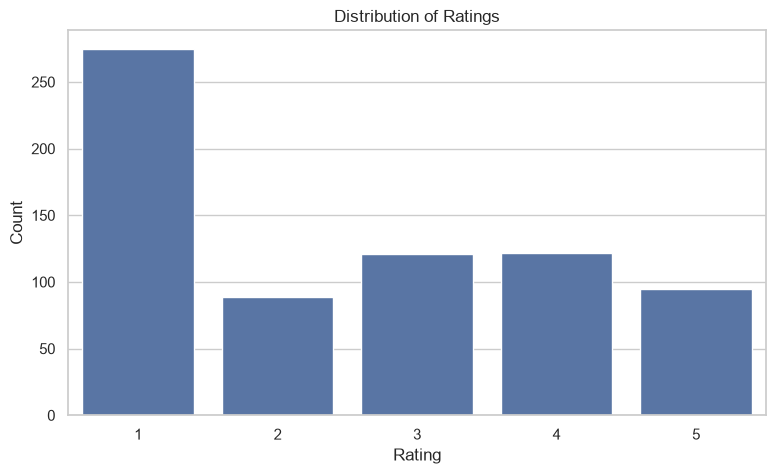

In [5]:
sns.set(style = 'whitegrid')
plt.figure(figsize = (9,5))
sns.countplot(data = df , x = 'Rating')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Adding Sentiment Labels in the Data
We will use Textblob library. Textblob provides a polarity scores raning from -1(very negative) to
1(very positive) for a given text . We can use this score to classify each review's sentiment as
positive, negative or neutral .

In [6]:
!pip install textblob

     ---------------------------------------- 0.0/57.4 kB ? eta -:--:--
     ---------------------------------------- 0.0/57.4 kB ? eta -:--:--
     ------- -------------------------------- 10.2/57.4 kB ? eta -:--:--
     --------------------------------- ---- 51.2/57.4 kB 525.1 kB/s eta 0:00:01
     -------------------------------------- 57.4/57.4 kB 604.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   --------------------------------- ----- 532.5/625.0 kB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 9.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.6 MB 5.7 MB/s eta 0:00:01
   ----------- ---------------------------- 0.4/1.6 MB 4.6 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.6 MB 5.0 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.6 MB 5.0 MB/s eta 0:00:01
   -------------- -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.17.0 requires filelock>=3.10.0, which is not installed.
huggingface-hub 1.17.0 requires httpx<1,>=0.23.0, which is not installed.
huggingface-hub 1.17.0 requires pyyaml>=5.1, which is not installed.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from textblob import TextBlob


In [8]:
def textblob_sentiment_analysis(review):
    sentiment = TextBlob(review).sentiment
    if sentiment.polarity > 0.1:
        return 'Positive'
    elif sentiment.polarity  < -0.1:
        return 'Negative'
    else:
        return 'Neutral'
df['sentiment'] = df['Review'].apply(textblob_sentiment_analysis)


In [10]:
df.sample(5)

,Review,Rating,sentiment
411,Heavy app. Why cant you sync linked in contact...,3,Negative
578,Update. Great new version. Finally have access...,4,Positive
419,Just updated it and now its not working. Keeps...,3,Positive
309,Nice app for the basics but I cannot access an...,3,Positive
526,"New interface is nice. Faster as well. ""Share ...",4,Positive


# Analyzing App Reviews Sentiments

In [12]:
sentiment_distribution = df['sentiment' ]. value_counts()
sentiment_distribution

sentiment
Positive    298
Neutral     297
Negative    107
Name: count, dtype: int64

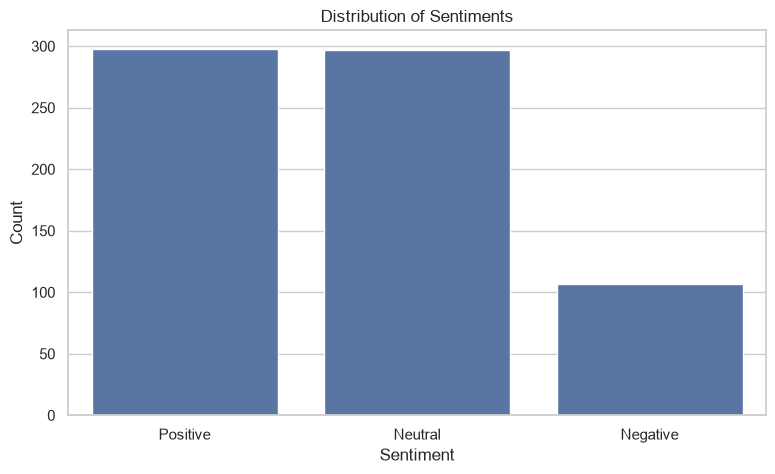

In [14]:
plt.figure(figsize = (9,5))
sns.barplot(x = sentiment_distribution.index,
y = sentiment_distribution.values)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()



So, we can see althrough the app has low
ratings , still the reviewers don't use many
negative words in the reviews for the app.
Next, we'll explore the relationship between the sentiments and the ratings. This analysis can help
us understand whether there is a correlation between the sentiment of the text and numerical
ratings.

<Figure size 1000x500 with 0 Axes>

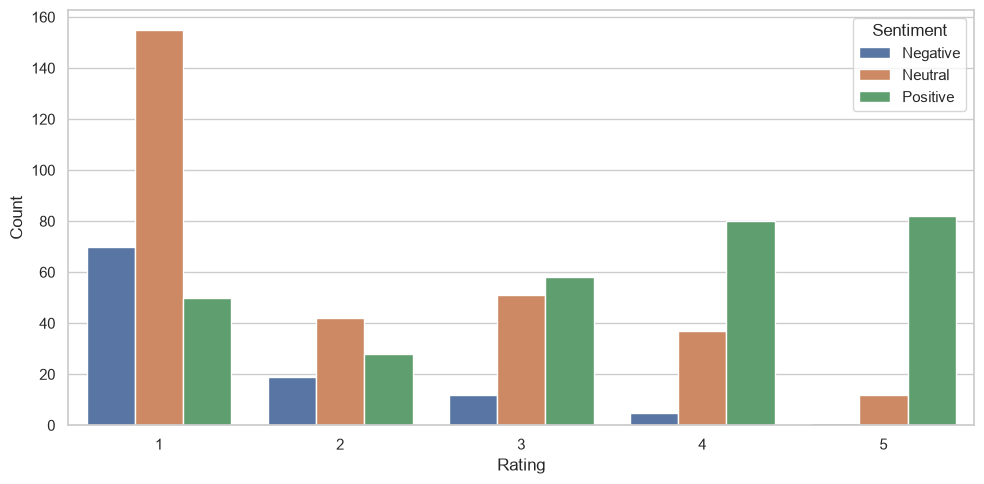

In [19]:
plt.figure(figsize=(10, 5))
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Rating', hue='sentiment')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


# Summary
App Reviews Sentiment Analysis is a valuable tool for app developers and business to understand
user feedback, prioritize feature updates and maintain a positive user community. It involves using
data analysis tchniques to determine whether the sentiments in these reviews are positive ,
negative or neutral.